# Machine Learning Assignment 2  
## Bank Marketing Classification

**Objective:** Predict whether a customer will subscribe to a term deposit using multiple classification models.

**Dataset:** `bank.csv`  
**Target Column:** `y`  
**Target Classes:** `yes`, `no`

This notebook implements the following models:

1. Logistic Regression  
2. Decision Tree Classifier  
3. K-Nearest Neighbor Classifier  
4. Naive Bayes Classifier  
5. Random Forest Classifier  

Evaluation metrics calculated:

- Accuracy
- AUC Score
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient, MCC

In [1]:
# ============================================================
# CELL 1: Import Required Libraries
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# CELL 2: Load Dataset
# ============================================================

# IMPORTANT:
# The uploaded bank.csv file uses semicolon as separator.
# Therefore, sep=";" is required.

df = pd.read_csv("C:/Users/DPE2THN/Downloads/bank.csv", sep=";")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape of dataset: (4521, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [3]:
# ============================================================
# CELL 3: Basic Dataset Information
# ============================================================

print("Dataset Information:")
print(df.info())

print("Column Names:")
print(df.columns.tolist())

print("Missing Values:")
print(df.isnull().sum())

print("Duplicate Rows:")
print(df.duplicated().sum())

print("Target Variable Distribution:")
print(df["y"].value_counts())

print("Target Variable Distribution Percentage:")
print((df["y"].value_counts(normalize=True) * 100).round(2))

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 826.8 KB
None
Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'd

In [4]:
# ============================================================
# CELL 4: Dataset Description
# ============================================================

display(df.describe(include="all"))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,4521.000000,4521,4521,4521,4521,4521.000000,4521,4521,4521,4521.000000,4521,4521.000000,4521.000000,4521.000000,4521.000000,4521,4521
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,management,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,969,2797,2306,4445,NaN,2559,3830,2896,NaN,1398,NaN,NaN,NaN,NaN,3705,4000
mean,41.170095,NaN,NaN,NaN,NaN,1422.657819,NaN,NaN,NaN,15.915284,NaN,263.961292,2.793630,39.766645,0.542579,NaN,NaN
std,10.576211,NaN,NaN,NaN,NaN,3009.638142,NaN,NaN,NaN,8.247667,NaN,259.856633,3.109807,100.121124,1.693562,NaN,NaN
min,19.000000,NaN,NaN,NaN,NaN,-3313.000000,NaN,NaN,NaN,1.000000,NaN,4.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,69.000000,NaN,NaN,NaN,9.000000,NaN,104.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,444.000000,NaN,NaN,NaN,16.000000,NaN,185.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,49.000000,NaN,NaN,NaN,NaN,1480.000000,NaN,NaN,NaN,21.000000,NaN,329.000000,3.000000,-1.000000,0.000000,NaN,NaN


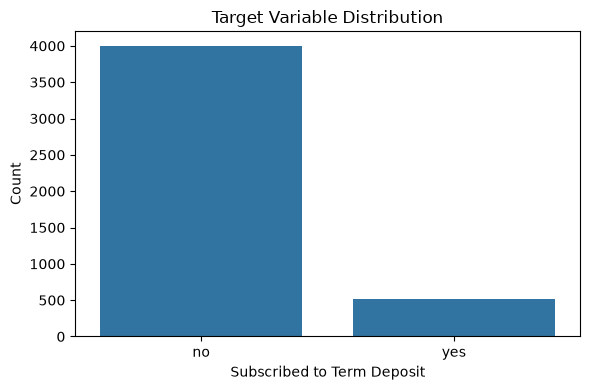

In [5]:
# ============================================================
# CELL 5: Target Variable Visualization
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Variable Distribution")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELL 6: Separate Features and Target
# ============================================================

X = df.drop("y", axis=1)
y = df["y"]

# Convert target variable into binary format
# yes = 1, no = 0
y = y.map({"no": 0, "yes": 1})

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("Target distribution after encoding:")
print(y.value_counts())

Feature shape: (4521, 16)
Target shape: (4521,)
Target distribution after encoding:
y
0    4000
1     521
Name: count, dtype: int64


In [7]:
# ============================================================
# CELL 7: Identify Numerical and Categorical Columns
# ============================================================

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [8]:
# ============================================================
# CELL 8: Train Test Split
# ============================================================

# Stratify is used because the dataset is imbalanced.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

print("Training target distribution:")
print(y_train.value_counts())

print("Testing target distribution:")
print(y_test.value_counts())

Training feature shape: (3616, 16)
Testing feature shape: (905, 16)
Training target shape: (3616,)
Testing target shape: (905,)
Training target distribution:
y
0    3199
1     417
Name: count, dtype: int64
Testing target distribution:
y
0    801
1    104
Name: count, dtype: int64


In [9]:
# ============================================================
# CELL 9: Save Test Data for Streamlit App
# ============================================================

# This test_data.csv can be uploaded in the Streamlit app.

test_data = X_test.copy()
test_data["y"] = y_test.map({0: "no", 1: "yes"})

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv saved successfully!")
display(test_data.head())

test_data.csv saved successfully!


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
2032,59,management,married,primary,no,1727,no,no,telephone,25,may,500,4,358,2,failure,yes
943,40,technician,married,secondary,no,109,no,no,unknown,20,jun,402,22,-1,0,unknown,no
408,44,management,married,secondary,no,438,yes,no,telephone,8,may,37,3,303,1,failure,no
3034,29,services,married,primary,no,-102,no,no,unknown,4,jul,134,1,-1,0,unknown,no
3447,53,management,married,tertiary,no,146,no,no,unknown,30,may,150,1,-1,0,unknown,no


In [10]:
# ============================================================
# CELL 10: Create Preprocessing Pipelines
# ============================================================

# For Logistic Regression, KNN, Naive Bayes, and SVM:
# Numerical features are scaled.
# Categorical features are one-hot encoded.

try:
    onehot_dense = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    onehot_sparse = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    # For older scikit-learn versions
    onehot_dense = OneHotEncoder(handle_unknown="ignore", sparse=False)
    onehot_sparse = OneHotEncoder(handle_unknown="ignore", sparse=True)

preprocessor_scaled_dense = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", onehot_dense, categorical_columns)
    ]
)

# For Decision Tree and Random Forest:
# Scaling is not mandatory.
# Categorical features are one-hot encoded.
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_columns),
        ("cat", onehot_sparse, categorical_columns)
    ]
)

print("Preprocessing pipelines created successfully!")

Preprocessing pipelines created successfully!


In [11]:
# ============================================================
# CELL 11: Define ML Models
# ============================================================

models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled_dense),
            ("classifier", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ]
    ),

    "Decision Tree": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("classifier", DecisionTreeClassifier(
                max_depth=6,
                class_weight="balanced",
                random_state=42
            ))
        ]
    ),

    "KNN": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled_dense),
            ("classifier", KNeighborsClassifier(
                n_neighbors=7
            ))
        ]
    ),

    "Naive Bayes": Pipeline(
        steps=[
            ("preprocessor", preprocessor_scaled_dense),
            ("classifier", GaussianNB())
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor_tree),
            ("classifier", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

}

print("Models created successfully!")
print(list(models.keys()))

Models created successfully!
['Logistic Regression', 'Decision Tree', 'KNN', 'Naive Bayes', 'Random Forest']


In [12]:
# ============================================================
# CELL 12: Function to Evaluate Models
# ============================================================

def evaluate_model(model, X_test, y_test):
    """
    This function calculates all required evaluation metrics:
    Accuracy, AUC, Precision, Recall, F1 Score, and MCC Score.
    """

    y_pred = model.predict(X_test)

    if hasattr(model.named_steps["classifier"], "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred

    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)

    return accuracy, auc, precision, recall, f1, mcc, y_pred, y_prob

print("Evaluation function created successfully!")

Evaluation function created successfully!


In [13]:
# ============================================================
# CELL 13: Train and Evaluate All Models
# ============================================================

results = []
trained_models = {}
model_predictions = {}

for model_name, model in models.items():
    print("=" * 70)
    print("Training Model:", model_name)

    model.fit(X_train, y_train)

    accuracy, auc, precision, recall, f1, mcc, y_pred, y_prob = evaluate_model(
        model, X_test, y_test
    )

    trained_models[model_name] = model
    model_predictions[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    results.append({
        "ML Model Name": model_name,
        "Accuracy": accuracy,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "MCC": mcc
    })

    print("Accuracy :", round(accuracy, 4))
    print("AUC      :", round(auc, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("MCC Score:", round(mcc, 4))

    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["no", "yes"],
        zero_division=0
    ))

Training Model: Logistic Regression
Accuracy : 0.8232
AUC      : 0.8908
Precision: 0.3716
Recall   : 0.7788
F1 Score : 0.5031
MCC Score: 0.4533
Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.83      0.89       801
         yes       0.37      0.78      0.50       104

    accuracy                           0.82       905
   macro avg       0.67      0.80      0.70       905
weighted avg       0.90      0.82      0.85       905

Training Model: Decision Tree
Accuracy : 0.8011
AUC      : 0.8054
Precision: 0.3403
Recall   : 0.7788
F1 Score : 0.4737
MCC Score: 0.4222
Classification Report:
              precision    recall  f1-score   support

          no       0.97      0.80      0.88       801
         yes       0.34      0.78      0.47       104

    accuracy                           0.80       905
   macro avg       0.65      0.79      0.68       905
weighted avg       0.89      0.80      0.83       905

Training Model: KN

In [14]:
# ============================================================
# CELL 14: Model Comparison Table
# ============================================================

results_df = pd.DataFrame(results)

results_df_rounded = results_df.copy()
for col in ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

print("Model Comparison Table:")
display(results_df_rounded)

Model Comparison Table:


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8232,0.8908,0.3716,0.7788,0.5031,0.4533
1,Decision Tree,0.8011,0.8054,0.3403,0.7788,0.4737,0.4222
2,KNN,0.8884,0.7997,0.5517,0.1538,0.2406,0.2492
3,Naive Bayes,0.8210,0.7881,0.3092,0.4519,0.3672,0.2737
4,Random Forest,0.8862,0.9079,0.5051,0.4808,0.4926,0.4287


In [15]:
# ============================================================
# CELL 15: Save Model Comparison Results
# ============================================================

results_df_rounded.to_csv("model_comparison_results.csv", index=False)

print("model_comparison_results.csv saved successfully!")

model_comparison_results.csv saved successfully!


In [16]:
# ============================================================
# CELL 16: Find Best Model
# ============================================================

# For imbalanced datasets, AUC, F1, and MCC are useful along with Accuracy.

best_model_by_auc = results_df.sort_values(by="AUC", ascending=False).iloc[0]
best_model_by_f1 = results_df.sort_values(by="F1", ascending=False).iloc[0]
best_model_by_mcc = results_df.sort_values(by="MCC", ascending=False).iloc[0]

print("Best Model by AUC:")
print(best_model_by_auc)

print("\n\nBest Model by F1:")
print(best_model_by_f1)

print("\n\nBest Model by MCC:")
print(best_model_by_mcc)

Best Model by AUC:
ML Model Name    Random Forest
Accuracy              0.886188
AUC                    0.90791
Precision             0.505051
Recall                0.480769
F1                    0.492611
MCC                   0.428725
Name: 4, dtype: object


Best Model by F1:
ML Model Name    Logistic Regression
Accuracy                    0.823204
AUC                          0.89081
Precision                    0.37156
Recall                      0.778846
F1                          0.503106
MCC                         0.453309
Name: 0, dtype: object


Best Model by MCC:
ML Model Name    Logistic Regression
Accuracy                    0.823204
AUC                          0.89081
Precision                    0.37156
Recall                      0.778846
F1                          0.503106
MCC                         0.453309
Name: 0, dtype: object


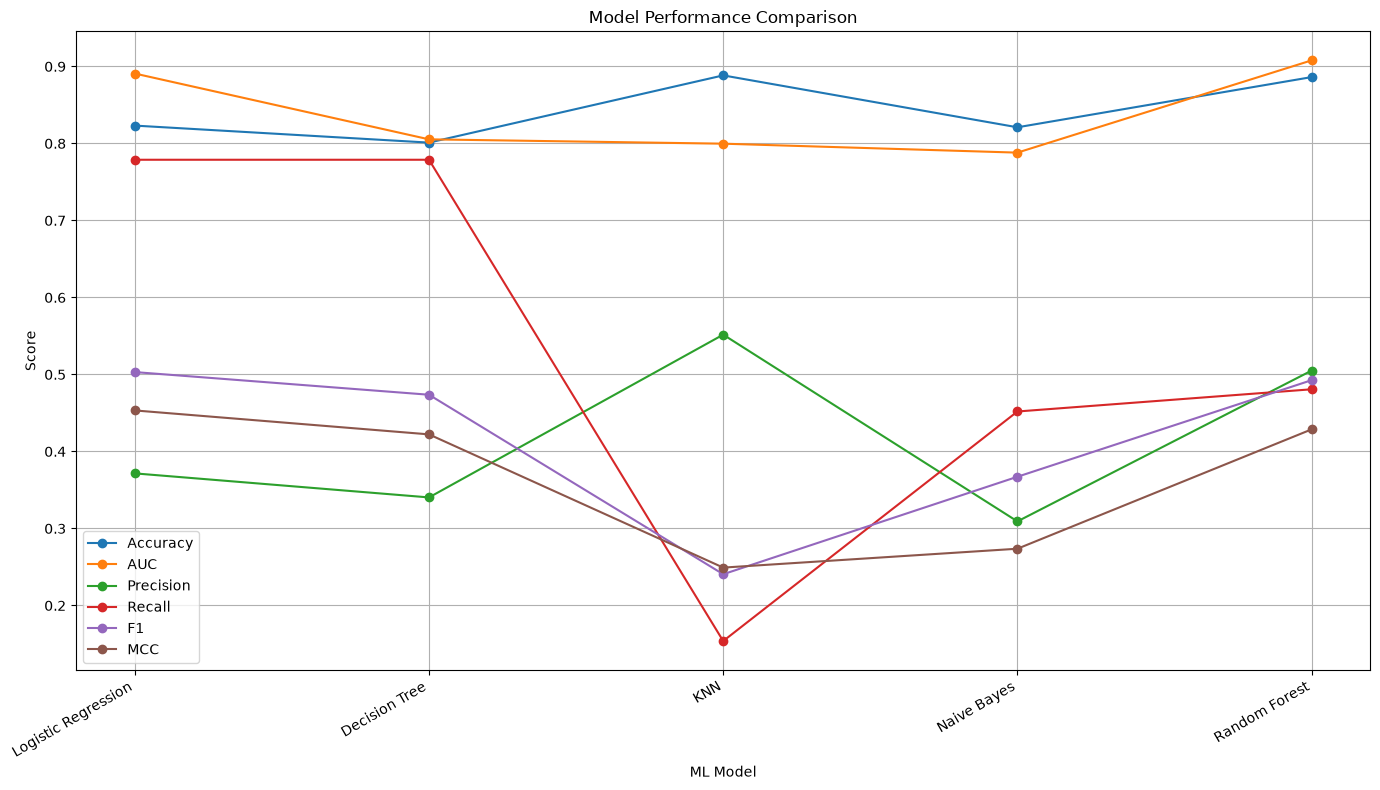

In [17]:
# ============================================================
# CELL 17: Plot Model Comparison
# ============================================================

metrics_to_plot = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]

plt.figure(figsize=(14, 8))

for metric in metrics_to_plot:
    plt.plot(
        results_df["ML Model Name"],
        results_df[metric],
        marker="o",
        label=metric
    )

plt.title("Model Performance Comparison")
plt.xlabel("ML Model")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

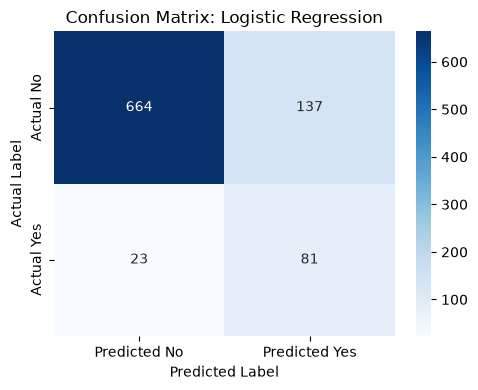

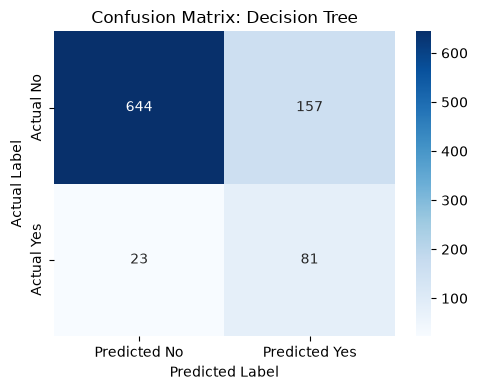

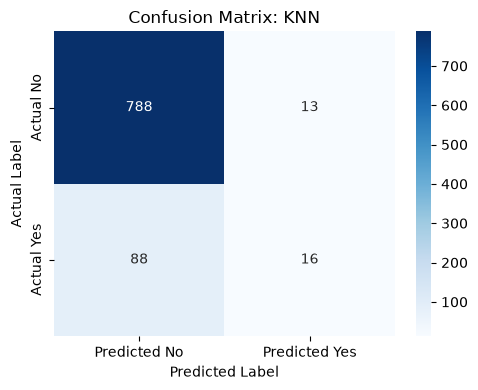

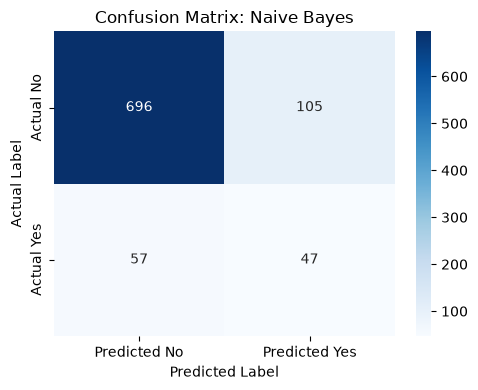

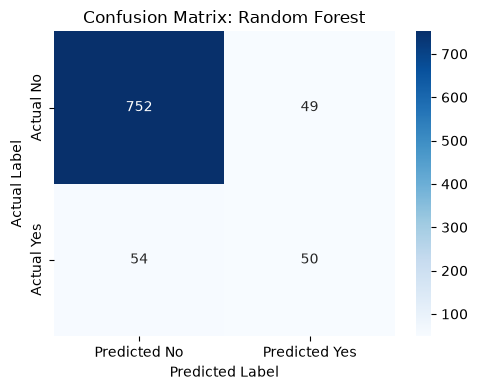

In [18]:
# ============================================================
# CELL 18: Confusion Matrix for Each Model
# ============================================================

for model_name, model in trained_models.items():
    y_pred = model_predictions[model_name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted No", "Predicted Yes"],
        yticklabels=["Actual No", "Actual Yes"]
    )
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()

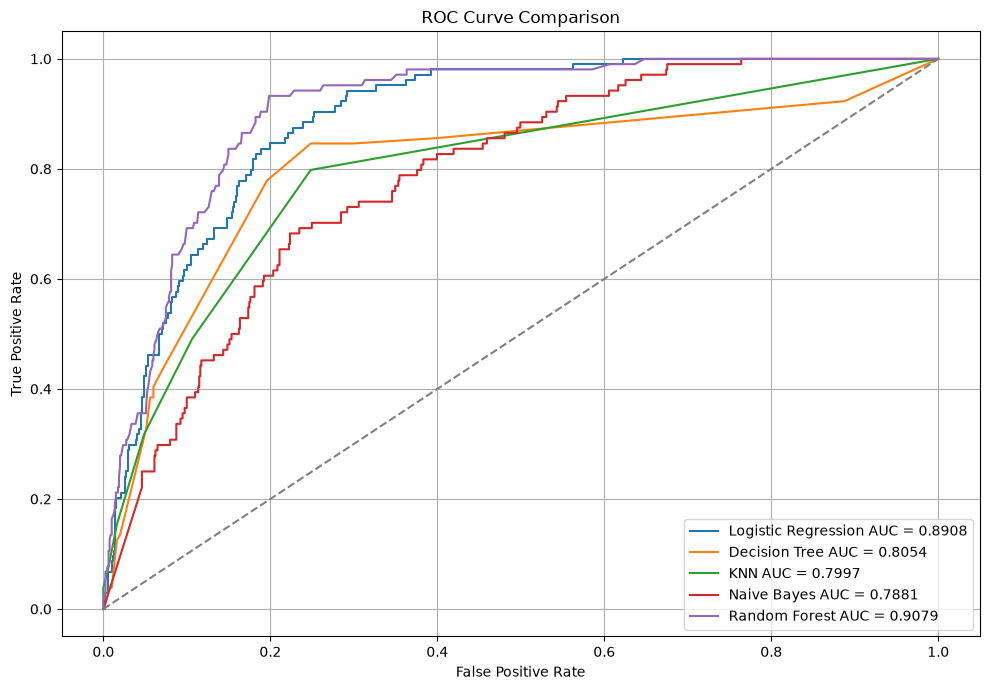

In [19]:
# ============================================================
# CELL 19: ROC Curve for Each Model
# ============================================================

plt.figure(figsize=(10, 7))

for model_name, model in trained_models.items():
    y_prob = model_predictions[model_name]["y_prob"]

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc_score:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CELL 20: Save All Trained Models
# ============================================================

os.makedirs("models", exist_ok=True)

for model_name, model in trained_models.items():
    file_name = model_name.lower().replace(" ", "_") + ".pkl"
    file_path = os.path.join("models", file_name)

    joblib.dump(model, file_path)
    print(f"Saved: {file_path}")

print("All models saved successfully!")

Saved: models\logistic_regression.pkl
Saved: models\decision_tree.pkl
Saved: models\knn.pkl
Saved: models\naive_bayes.pkl
Saved: models\random_forest.pkl
All models saved successfully!


In [21]:
# ============================================================
# CELL 21: Save Best Model Separately
# ============================================================

best_model_name = best_model_by_auc["ML Model Name"]
best_model = trained_models[best_model_name]

joblib.dump(best_model, "best_model.pkl")

print("Best model saved as best_model.pkl")
print("Best Model:", best_model_name)

Best model saved as best_model.pkl
Best Model: Random Forest


In [22]:
# ============================================================
# CELL 22: Feature Importance for Random Forest
# ============================================================

rf_model = trained_models["Random Forest"]

preprocessor = rf_model.named_steps["preprocessor"]
classifier = rf_model.named_steps["classifier"]

encoded_cat_features = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_columns)
all_feature_names = numerical_columns + list(encoded_cat_features)

feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 Random Forest Feature Importances:")
display(feature_importance.head(15))

Top 15 Random Forest Feature Importances:


,Feature,Importance
3,duration,0.327975
1,balance,0.079480
0,age,0.073331
2,day,0.064253
4,campaign,0.035382
5,pdays,0.030010
49,poutcome_success,0.024396
6,previous,0.022428
34,contact_unknown,0.020311
45,month_oct,0.016971


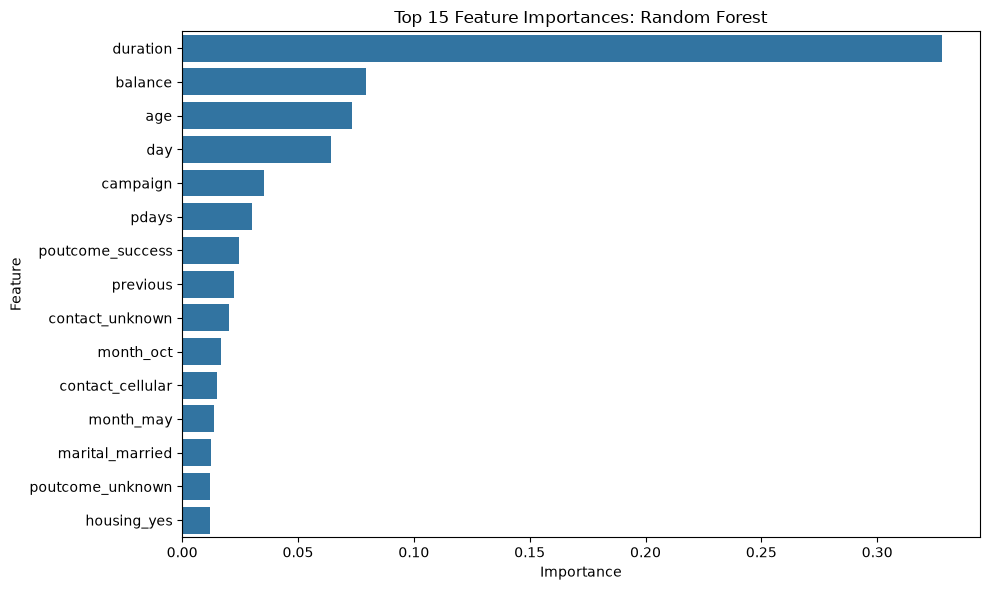

In [23]:
# ============================================================
# CELL 23: Plot Top 15 Feature Importances
# ============================================================

plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)
plt.title("Top 15 Feature Importances: Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 24: Save Feature Importance
# ============================================================

feature_importance.to_csv("random_forest_feature_importance.csv", index=False)

print("random_forest_feature_importance.csv saved successfully!")

random_forest_feature_importance.csv saved successfully!


## Final README Observation Draft

The Bank Marketing dataset is a binary classification dataset where the objective is to predict whether a customer will subscribe to a term deposit. The target variable is imbalanced, with a larger number of 'no' responses compared to 'yes' responses. Therefore, accuracy alone is not sufficient for model evaluation. Additional metrics such as AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient were used for fair comparison.

Logistic Regression provided a strong baseline and performed well after scaling and one-hot encoding. Decision Tree was easy to interpret but required depth control to reduce overfitting. KNN was sensitive to scaling and class imbalance. Naive Bayes was fast and simple but its independence assumption may not fully match the dataset. Random Forest performed strongly due to ensemble learning and its ability to capture non-linear patterns. Support Vector Machine was included as an additional model for completeness.

In [25]:
# ============================================================
# CELL 25: Final Summary for README
# ============================================================

print("Final Model Comparison Table:")
display(results_df_rounded)

print("Dataset Summary:")
print(f"Total Records: {df.shape[0]}")
print(f"Input Features: {X.shape[1]}")
print("Target Column: y")
print("Problem Type: Binary Classification")

print("Suggested Overall Winner:")
print(best_model_name)

Final Model Comparison Table:


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8232,0.8908,0.3716,0.7788,0.5031,0.4533
1,Decision Tree,0.8011,0.8054,0.3403,0.7788,0.4737,0.4222
2,KNN,0.8884,0.7997,0.5517,0.1538,0.2406,0.2492
3,Naive Bayes,0.8210,0.7881,0.3092,0.4519,0.3672,0.2737
4,Random Forest,0.8862,0.9079,0.5051,0.4808,0.4926,0.4287


Dataset Summary:
Total Records: 4521
Input Features: 16
Target Column: y
Problem Type: Binary Classification
Suggested Overall Winner:
Random Forest
